## 1. Data Reading

- PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often - family members, but not always.
- HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
- CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- Destination - The planet the passenger will be debarking to.
- Age - The age of the passenger.
- VIP - Whether the passenger has paid for special VIP service during the voyage.
- RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
- Name - The first and last names of the passenger.
- Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X = pd.read_csv('./dataset/train.csv')
X.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


### 1.1 Target data of distribution

<Axes: xlabel='Transported', ylabel='count'>

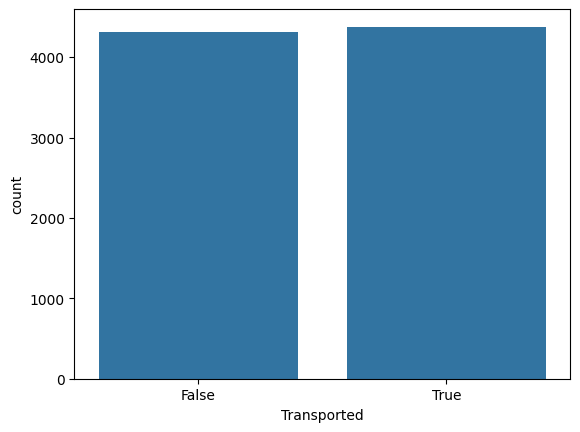

In [26]:
target = X['Transported']
sns.countplot(x = target)

In [27]:
np.round(len(X.iloc[X['Transported'] == 1]) / len(X['Transported']), 4)

np.float64(0.5036)

ratio of true of target data is 50.36%. We don't need Data Augmentation

### 1.2 Null of Dataset

In [28]:
X.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

### 1.3 Check duplicated values

In [29]:
X.duplicated().sum()

np.int64(0)

There is no duplicated values

### 1.4 Cardinality

In [30]:
X.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

## 1.5 Data types

In [125]:
X.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

1. Numerical data 
- Age
- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck
2. Categorial data (One-Hot encoding)
- PassengerId
- HomePlanet
- Cryosleep
- Cabin
- Destination
- VIP
- Name

## 2. EDA

### 2.1 Age distribution

<Axes: xlabel='Age', ylabel='Count'>

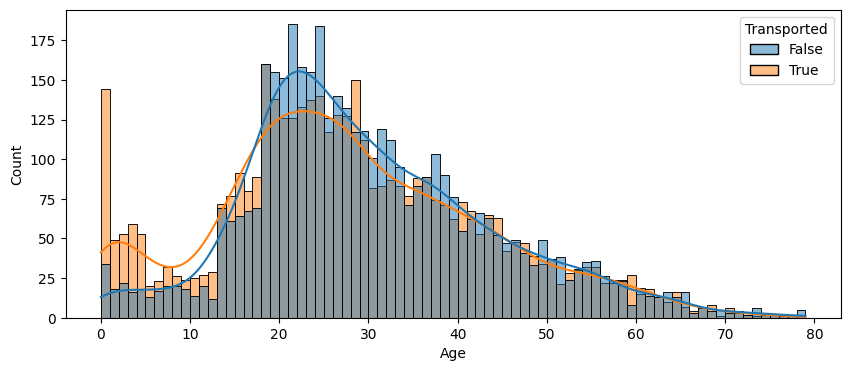

In [50]:
fig = plt.figure(figsize=(10, 4))
sns.histplot(x=X['Age'], hue=X['Transported'], binwidth=1, kde=True)

While the 18-and-under group showed more 'True' cases, 'False' results predominated in the 19 to 40 age bracket

- Notes
1. New feature "Age_group" (1 to 18, 19 to 40, 40 ~) is needed

### 2.2 Expenditure distribution

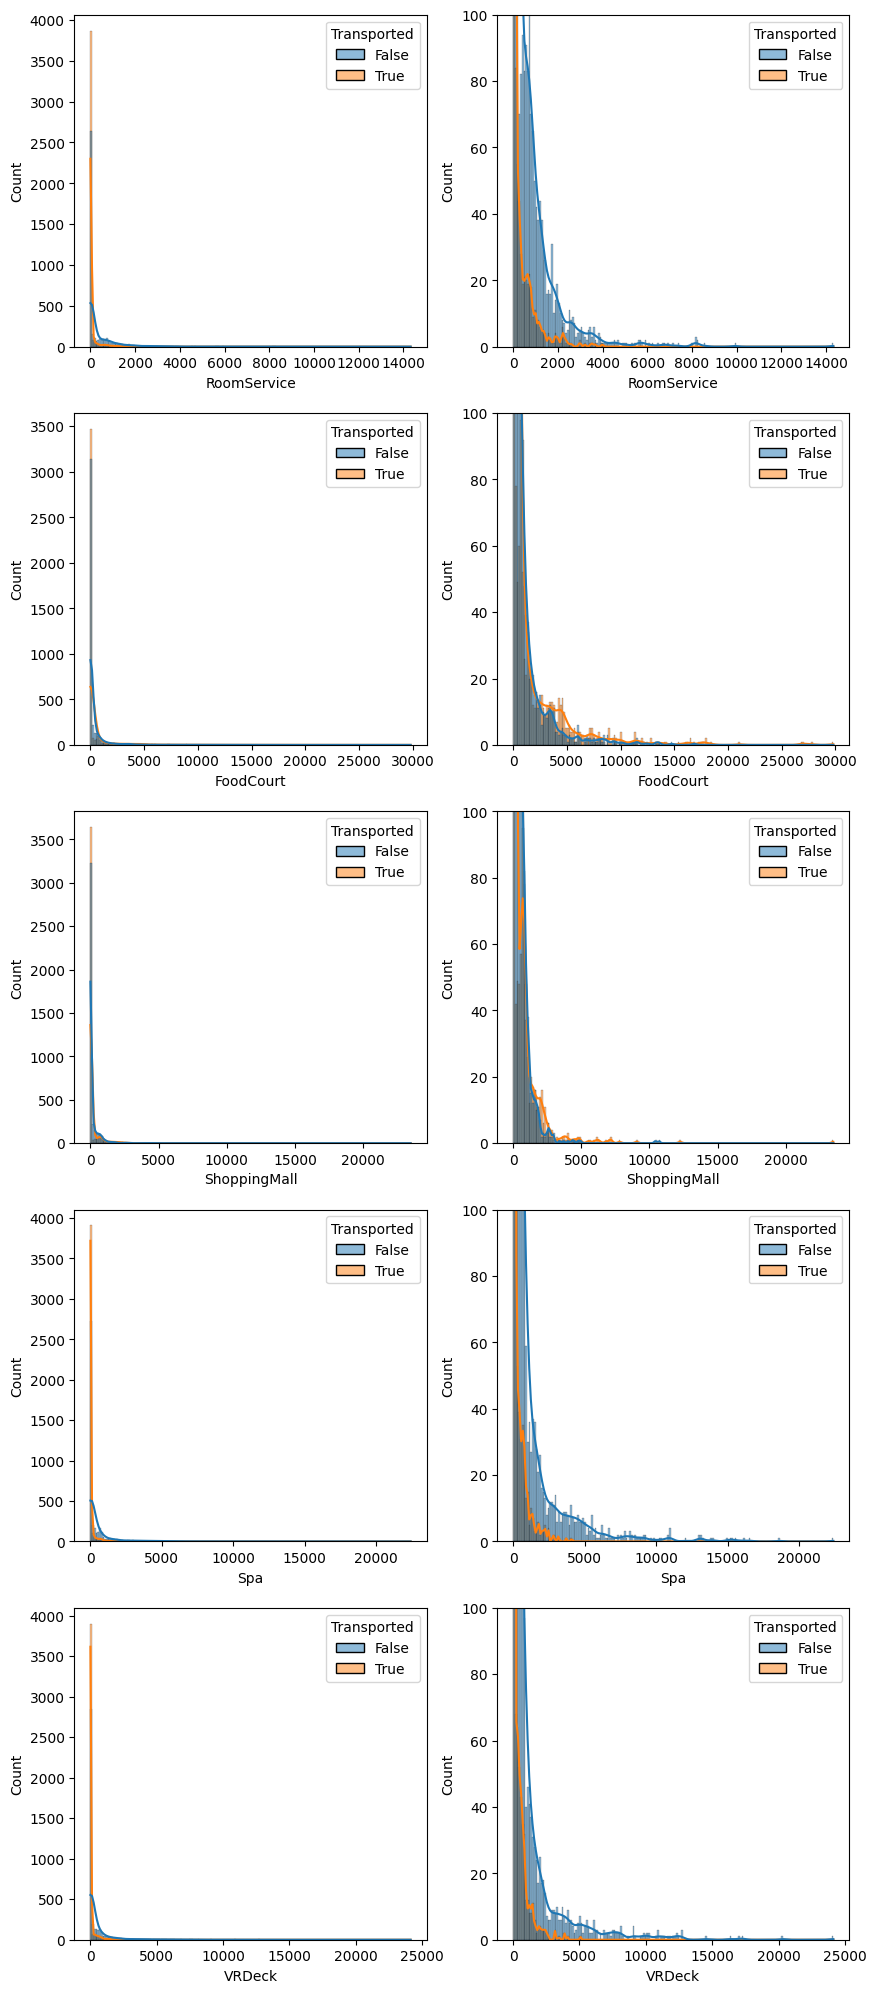

In [81]:
expenditure = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(5, 2, figsize=(10, 25))
axes_list = axes.flatten()

for i, exp in enumerate(expenditure):
    sns.histplot(x=X[exp], ax=axes_list[2*i], kde=True, hue=X['Transported'])

    plt.ylim(0, 1)
    sns.histplot(x=X[exp], ax=axes_list[2*i + 1], kde=True, hue=X['Transported'])
    axes_list[2*i + 1].set_ylim(0, 100)    
    

Notes:
- The majority of passengers had zero expenditure.
- "Since non-spending passengers show higher survival rates, we should engineer a new feature, 'No_spending'"
- There are a small number of outliers
- RoomService, Spa and VRDeck have different distributions to FoodCourt and ShoppingMall

Insight:
- create new feature "total_expenditure"
- create new feature "No_spending"
- Create "Essential" / "Luxury" → "Categorize spending into 'Essential' (FoodCourt, ShoppingMall) and 'Luxury' (RoomService, Spa, VRDeck) to capture different consumption patterns.
- Take the log transform to reduce skew


### 2.3 PassengerId

In [83]:
X['PassengerId'].head(5)

0    0001_01
1    0002_01
2    0003_01
3    0003_02
4    0004_01
Name: PassengerId, dtype: str

- Notes
1. passengerId takes the form gggg_pp.
2. we can extract group_number and personal_number in group

### 2.4  HomePlanet

<Axes: xlabel='HomePlanet', ylabel='count'>

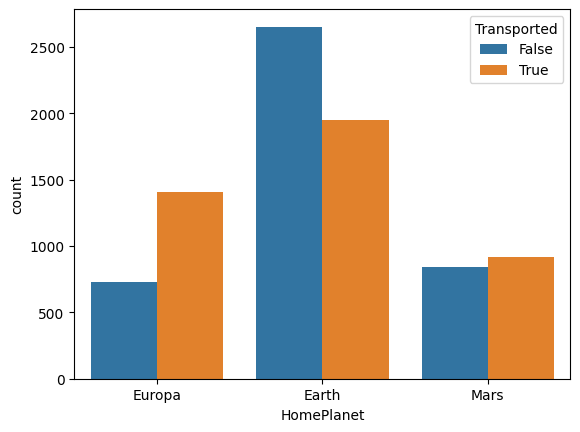

In [88]:
sns.countplot(x = X['HomePlanet'], hue=X['Transported'])

In [109]:
X.groupby(['HomePlanet'])['Transported'].mean()

HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64

- Notes
1. 65% of passengers from Europa was transported
2. 42% of passengers from Earth was not transported

### 2.5 CryoSleep

<Axes: xlabel='CryoSleep', ylabel='count'>

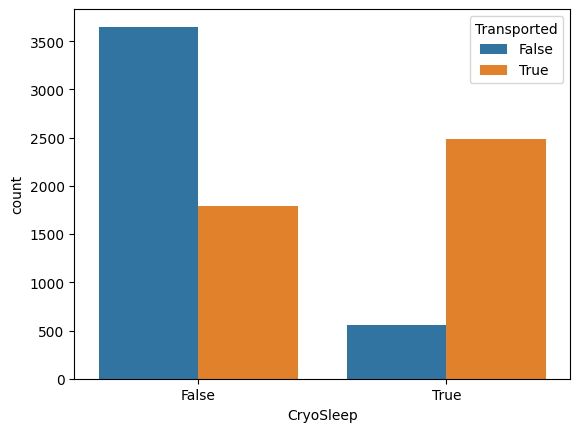

In [110]:
sns.countplot(x=X['CryoSleep'], hue=X['Transported'])

In [111]:
X.groupby(X['CryoSleep'])['Transported'].mean()

CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64

- Notes
1. 81% of passengers in CryoSleep was transported (It is very important information)


### 2.6 Cabin

In [112]:
X['Cabin'].head(5)

0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
Name: Cabin, dtype: str

- Notes
1. Cabin takes the form deck/num/side. So we can extract Cabin to cabin_deck, cabin_num, cabin_side
2. cabin_side has two values P, S

### 2.7 Destination

<Axes: xlabel='Destination', ylabel='count'>

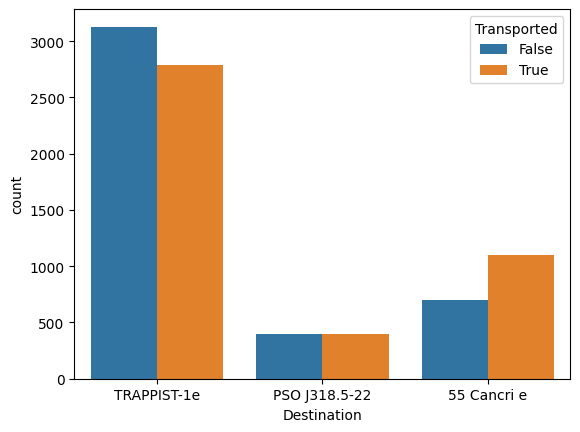

In [113]:
sns.countplot(x=X['Destination'], hue=X['Transported'])

### 2.8 VIP

<Axes: xlabel='VIP', ylabel='count'>

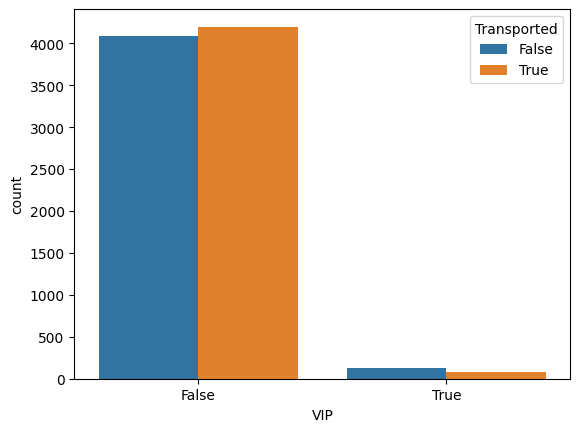

In [114]:
sns.countplot(x=X['VIP'], hue=X['Transported'])

In [118]:
len(X.loc[X['VIP'] == False]) / len(X)

0.9537558955481422

In [115]:
X.groupby(X['VIP'])['Transported'].mean()

VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64

- Notes

The 'VIP' feature is not very informative because the vast majority of passengers are non-VIPs, and the transportation rate among them is nearly identical

So we can drop it

### 2.9 Name

In [120]:
X['Name'].head(10)

0       Maham Ofracculy
1          Juanna Vines
2         Altark Susent
3          Solam Susent
4     Willy Santantines
5     Sandie Hinetthews
6    Billex Jacostaffey
7    Candra Jacostaffey
8         Andona Beston
9        Erraiam Flatic
Name: Name, dtype: str

- Notes
1. We can extract the 'Surname' from the 'Name' feature
2. It is assumed that passengers with the same surname belong to the same family